<a href="https://colab.research.google.com/github/Temu-Bire/Job-board/blob/main/Student_health_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train=pd.read_csv('/content/drive/MyDrive/Student_health_risk/train.csv')
test=pd.read_csv('/content/drive/MyDrive/Student_health_risk/test.csv')


In [ ]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [ ]:
train.tail()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [ ]:
train.shape

(690088, 15)

In [ ]:
test.shape

(295753, 14)

In [ ]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [ ]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


In [ ]:
# Numeric columns in train
train_numeric = train.select_dtypes(include='number').columns.drop('id')

# Keep only columns that also exist in test
common_numeric = train_numeric.intersection(test.columns)

# Compute means from training data
train_means = train[common_numeric].mean()

# Fill missing values
train[common_numeric] = train[common_numeric].fillna(train_means)
test[common_numeric] = test[common_numeric].fillna(train_means)

In [ ]:
# Categorical columns in train
categorical_cols = train.select_dtypes(include=['object']).columns

# Keep only columns that also exist in test
common_categorical = categorical_cols.intersection(test.columns)

# Fill missing values using the mode from the training data
for col in common_categorical:
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)

In [ ]:
train.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0


In [ ]:
test.isnull().sum()

,0
id,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0
stress_level,0


In [ ]:
for col in categorical_cols:
    print(col)
    print(train[col].unique())
    print()

health_condition
['unhealthy' 'at-risk' 'fit']

diet_type
['veg' 'non-veg' 'balanced']

stress_level
['high' 'low' 'medium']

sleep_quality
['average' 'poor' 'good']

physical_activity_level
['sedentary' 'moderate' 'active']

smoking_alcohol
['yes' 'occasional' 'no']

gender
['female' 'other' 'male']



In [ ]:
# Define mappings
ordinal_mappings = {
    "stress_level": {
        "low": 0,
        "medium": 1,
        "high": 2
    },
    "sleep_quality": {
        "poor": 0,
        "average": 1,
        "good": 2
    },
    "physical_activity_level": {
        "sedentary": 0,
        "moderate": 1,
        "active": 2
    },
    "health_condition": {
        "unhealthy": 0,
        "at-risk": 1,
        "fit": 2
    },
    "smoking_alcohol": {
        "no": 0,
        "occasional": 1,
        "yes": 2
    }
}

# Apply mappings to both train and test
for col, mapping in ordinal_mappings.items():
    if col in train.columns:
        train[col] = train[col].map(mapping)

    if col in test.columns:
        test[col] = test[col].map(mapping)

In [ ]:
# One-hot encode both datasets
train = pd.get_dummies(
    train,
    columns=["gender", "diet_type"],
    drop_first=True
)

test = pd.get_dummies(
    test,
    columns=["gender", "diet_type"],
    drop_first=True
)

# Make sure train and test have the same columns
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [ ]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender_male,gender_other,diet_type_non-veg,diet_type_veg
0,0,0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,1,0,2,False,False,False,True
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0,1,1,2,False,True,True,False
2,2,0,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,2,2,True,False,False,True
3,3,0,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,1,2,1,False,False,False,True
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,1,1,0,2,True,False,False,True


In [ ]:
test = test.drop('health_condition', axis=1)
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender_male,gender_other,diet_type_non-veg,diet_type_veg
0,690088,5.350000,64.9,23.48,2745.0,14167.0,59.5,1.86,2,0,2,1,True,False,False,True
1,690089,6.992597,83.1,22.42,1773.0,6801.0,24.5,2.40,2,0,0,2,False,True,False,False
2,690090,6.680000,59.7,24.14,3040.0,13250.0,48.5,2.76,1,0,2,0,True,False,False,False
3,690091,7.130000,78.5,26.26,2494.0,6331.0,56.9,2.34,0,2,1,2,False,True,False,True
4,690092,5.490000,77.7,23.29,1828.0,13894.0,39.4,2.45,2,1,2,1,False,True,False,True


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X=train.drop(columns=['id','health_condition'])
y=train['health_condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
test_scaled = scaler.transform(test.drop(columns=['id']))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model=LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred))

0.9472967294121056


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  8270   3155     13]
 [  1046 116827    748]
 [    21   2291   5647]]


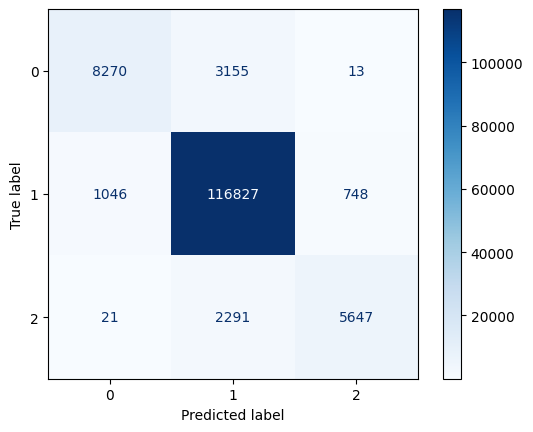

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80     11438
           1       0.96      0.98      0.97    118621
           2       0.88      0.71      0.79      7959

    accuracy                           0.95    138018
   macro avg       0.91      0.81      0.85    138018
weighted avg       0.95      0.95      0.94    138018



In [ ]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender_male,gender_other,diet_type_non-veg,diet_type_veg
0,690088,5.350000,64.9,23.48,2745.0,14167.0,59.5,1.86,2,0,2,1,True,False,False,True
1,690089,6.992597,83.1,22.42,1773.0,6801.0,24.5,2.40,2,0,0,2,False,True,False,False
2,690090,6.680000,59.7,24.14,3040.0,13250.0,48.5,2.76,1,0,2,0,True,False,False,False
3,690091,7.130000,78.5,26.26,2494.0,6331.0,56.9,2.34,0,2,1,2,False,True,False,True
4,690092,5.490000,77.7,23.29,1828.0,13894.0,39.4,2.45,2,1,2,1,False,True,False,True


In [ ]:
test.isnull().sum()[test.isnull().sum()>0]


,0


In [ ]:
submission=model.predict(test_scaled)
submission_df=pd.DataFrame({'id':test['id'],'health_condition':submission})
submission_df.to_csv('submission.csv',index=False)

In [ ]:
train['health_condition'].value_counts()/train.shape[0]*100


,count
health_condition,
1,85.867455
0,8.364730
2,5.767815


In [ ]:
submission_df['health_condition'].value_counts()/submission_df.shape[0]*100

,count
health_condition,
1,88.666894
0,6.702552
2,4.630553


In [ ]:
from google.colab import  files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>